# Density of population and building ages in Barcelona

## Libraries

In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import mapclassify

plt.style.use('../map.mplstyle')

## Data

Data is obtained from the Open Data Portal of the Ajuntament de
Barcelona, and from a curated GitHub repository containing the
geographical information on the partitioning of the city in
“Districtes”, “Barris”, and “Seccions Censals”.

In [2]:
# from https://opendata-ajuntament.barcelona.cat/data/ca/dataset/est-cadastre-edificacions-edat-mitjana/resource/4b0e0ac1-eade-4055-bea3-f07e2a79a7b4
edat_edificacions_fname = "../data/2026_edificacions_edat_mitjana.csv"

# from https://opendata-ajuntament.barcelona.cat/data/ca/dataset/pad_mdbas/resource/eb82adf2-a7b0-40e6-9624-b4b9eff23018
population_fname = "../data/2025_pad_mdbas.csv"

# from https://github.com/martgnz/bcn-geodata/blob/master/seccio-censal/seccio-censal.geojson
seccio_censal_geojson_fname = "../data/seccio-censal.geojson"

# from https://github.com/martgnz/bcn-geodata/blob/master/barris/barris.geojson
barris_geojson_fname = "../data/barris.geojson"

# from https://github.com/martgnz/bcn-geodata/blob/master/districtes/districtes.geojson
districtes_geojson_fname = "../data/districtes.geojson"

In [3]:
# load seccio_censal geojson file
seccio_censal = gpd.read_file(seccio_censal_geojson_fname)

# fix data type of columns
seccio_censal["SEC_CENS"] = seccio_censal["SEC_CENS"].astype(int)
seccio_censal["BARRI"] = seccio_censal["BARRI"].astype(int)
seccio_censal["DISTRICTE"] = seccio_censal["DISTRICTE"].astype(int)

# select columns we need
seccio_censal = seccio_censal[['SEC_CENS', 'BARRI', 'DISTRICTE', 'AREA', 'geometry']]
seccio_censal.head()

In [4]:
# load Barris geojson file
barris = gpd.read_file(barris_geojson_fname)

barris["BARRI"] = barris["BARRI"].astype(int)
barris["DISTRICTE"] = barris["DISTRICTE"].astype(int)
barris = barris[['BARRI', 'DISTRICTE', 'NOM', 'geometry']].rename(columns={'NOM':'NOM_BARRI'})
barris.head()

In [5]:
# load Districtes geojson file
districtes = gpd.read_file(districtes_geojson_fname)
districtes['DISTRICTE'] = districtes['DISTRICTE'].astype(int)
districtes = districtes[['DISTRICTE', 'NOM', 'geometry']].rename(columns={'NOM':'NOM_DISTRICTE'})
districtes.head()

In [6]:
# load data on the mean age of the construction, keeping only the code of the seccio_censal
# and the data point relative to the mean construction age
edat = pd.read_csv(edat_edificacions_fname)
edat = edat.rename(
    columns={'Seccio_censal':'SEC_CENS', 'Codi_barri':'BARRI', 'Codi_districte':'DISTRICTE'})\
        [['SEC_CENS', 'BARRI', 'DISTRICTE','Edat_mitjana']]
edat.head()

In [7]:
# load data on the number of people living in each "Secció Censal"
population = pd.read_csv(population_fname)
population['SEC_CENS'] = population['Seccio_Censal'].apply(lambda x:int(str(x)[-3:]))
population = population.rename(columns={'Codi_Districte':'DISTRICTE', 'Valor':'population'})\
    [['DISTRICTE', 'SEC_CENS', 'population']]
population.head()

In [8]:
# this is the GeoDataFrame that will be used for plotting the maps
gdf = seccio_censal.merge(edat, how='left').merge(population, how='left')
gdf['density'] = gdf['population']/gdf['AREA']
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   SEC_CENS      1068 non-null   int64   
 1   BARRI         1068 non-null   int64   
 2   DISTRICTE     1068 non-null   int64   
 3   AREA          1068 non-null   float64 
 4   geometry      1068 non-null   geometry
 5   Edat_mitjana  1055 non-null   float64 
 6   population    1068 non-null   int64   
 7   density       1068 non-null   float64 
dtypes: float64(3), geometry(1), int64(4)
memory usage: 66.9 KB

## Plots

### Bivariate map

In [9]:
gdf['x_group'] = gdf[['Edat_mitjana']].apply(mapclassify.Quantiles.make(rolling=True, k = 3))
gdf['y_group'] = gdf[['density']].apply(mapclassify.Quantiles.make(rolling=True, k = 3))
gdf['xy_group'] = gdf['x_group'].astype(str) + "-" + gdf['y_group'].astype(str)
gdf.head()

In [25]:
color_mapping = {
    "0-0": "#f0f0f0",
    "1-0": "#b3cde3",
    "2-0": "#6497b1",

    "0-1": "#fdbb84",
    "1-1": "#9e9e9e",
    "2-1": "#4f81a3",

    "0-2": "#e34a33",
    "1-2": "#b3588a",
    "2-2": "#2c3e75"
}

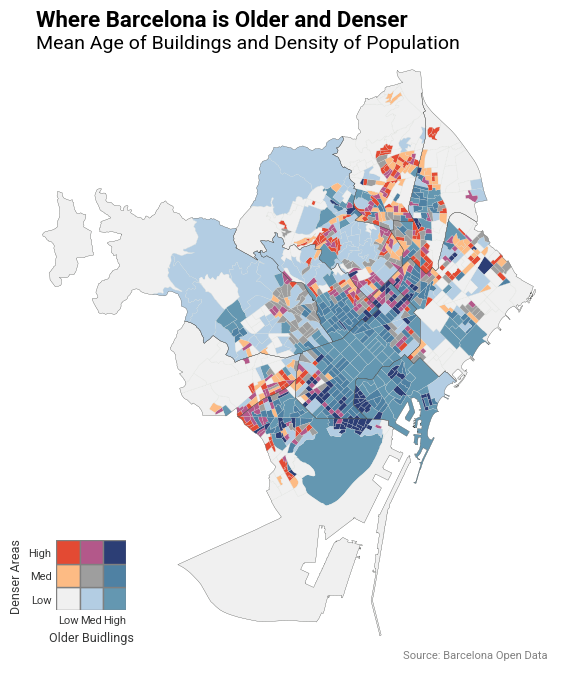

In [31]:
# calculate the max and min of the age of the buildings
import contextily as ctx

# gdf = gdf.to_crs(epsg=3857)
# districtes = districtes.to_crs(epsg=3857)

scale = 0.7
fig, ax = plt.subplots(figsize=(scale*10, scale*12))
gdf.plot(
    categorical = True,
    edgecolor = "xkcd:light grey",
    linewidth = 0.2,
    linestyle='--',
    ax = ax,
    color=gdf["xy_group"].map(color_mapping),
).set_axis_off();

districtes.plot(
    ax=ax,
    facecolor='none',
    edgecolor='k',
    linewidth=0.15)

# ctx.add_basemap(
#     ax,
#     source=ctx.providers.CartoDB.Positron,
#     alpha=0.5  # key: keep it subtle
# )

# --- Create inset axis for legend ---
legend_ax = fig.add_axes([0.18, 0.18, 0.1, 0.1])  # [left, bottom, width, height]
legend_ax.set_aspect('equal')

# --- Build 3x3 color grid ---
legend_grid = np.array([
    ["0-0", "1-0", "2-0"],
    ["0-1", "1-1", "2-1"],
    ["0-2", "1-2", "2-2"]
])

color_grid = [[color_mapping[cell] for cell in row] for row in legend_grid]

# --- Plot as image ---
for i in range(3):
    for j in range(3):
        legend_ax.add_patch(plt.Rectangle(
            (j, i), 1, 1,
            facecolor=color_grid[i][j],
            edgecolor='gray'
        ))

legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)

# Remove ticks
legend_ax.set_xticks([])
legend_ax.set_yticks([])

# --- Axis labels ---
legend_ax.set_xlabel("Older Buidlings", fontsize=9)
legend_ax.set_ylabel("Denser Areas", fontsize=9)

legend_ax.set_xticks([0.5, 1.5, 2.5])
legend_ax.set_xticklabels(["Low", "Med", "High"], fontsize=8)
legend_ax.tick_params('both', length=0)

legend_ax.set_yticks([0.5, 1.5, 2.5])
legend_ax.set_yticklabels(["Low", "Med", "High"], fontsize=8)

# Clean frame
for spine in legend_ax.spines.values():
    spine.set_visible(False)

ax.text(
    2.05, 41.48, "Where Barcelona is Older and Denser",
    fontsize=16, weight='bold'
)

ax.text(
    2.05, 41.474, "Mean Age of Buildings and Density of Population",
    fontsize=14
)

ax.text(
    0.71, 0.01,
    "Source: Barcelona Open Data",
    transform=ax.transAxes,
    fontsize=8,
    color="gray"
)

fig.savefig('map.png', bbox_inches='tight', dpi=600)
ax.axis('off')
plt.show()

Text(0, 0.5, 'Mean density of population (hab/m²)')

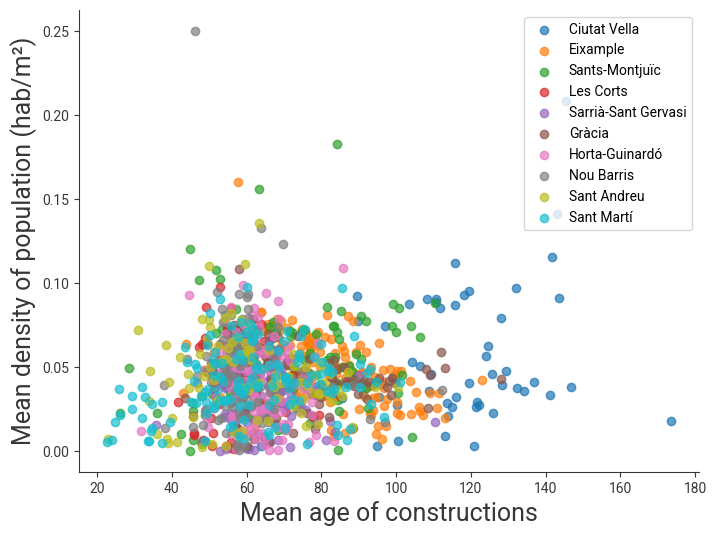

In [11]:
plot_df = population_gdf.merge(df).merge(districtes[['DISTRICTE', 'NOM_DISTRICTE']], on='DISTRICTE')

fig, ax = plt.subplots(figsize=(8,6))
for districte in plot_df['DISTRICTE'].unique():
    tmp = plot_df[plot_df['DISTRICTE']==districte]
    nom_districte = districtes.set_index('DISTRICTE')['NOM_DISTRICTE'][districte]
    ax.scatter(tmp['Edat_mitjana'], tmp['density'], label=nom_districte, alpha=0.7)

ax.legend(loc='upper right', frameon=True)

ax.set_xlabel("Mean age of constructions")
ax.set_ylabel("Mean density of population (hab/m²)")

Text(0, 0.5, 'Mean density of population (hab/m²)')

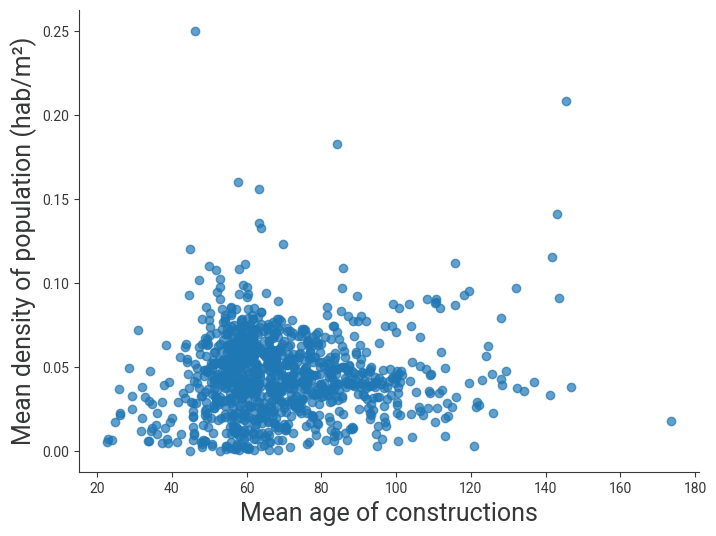

In [12]:
plot_df = population_gdf.merge(df).merge(districtes[['DISTRICTE', 'NOM_DISTRICTE']], on='DISTRICTE')

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(plot_df['Edat_mitjana'], plot_df['density'], alpha=0.7)

ax.set_xlabel("Mean age of constructions")
ax.set_ylabel("Mean density of population (hab/m²)")

In [13]:
barris_df = pd.DataFrame({
    'area':seccio_censal.groupby('BARRI').AREA.sum(),
    'Edat_mitjana':df.groupby('BARRI').Edat_mitjana.mean(),
    'population':population.merge(seccio_censal).groupby('BARRI')['population'].sum()
}).reset_index()
barris_df['density'] = barris_df['population']/barris_df['area']
barris_df = barris_df.merge(barris[['BARRI', 'DISTRICTE', 'NOM_BARRI']])\
    .merge(districtes[['DISTRICTE', 'NOM_DISTRICTE']])
barris_df

73 rows × 8 columns

Text(0, 0.5, 'Mean density of population (hab/m²)')

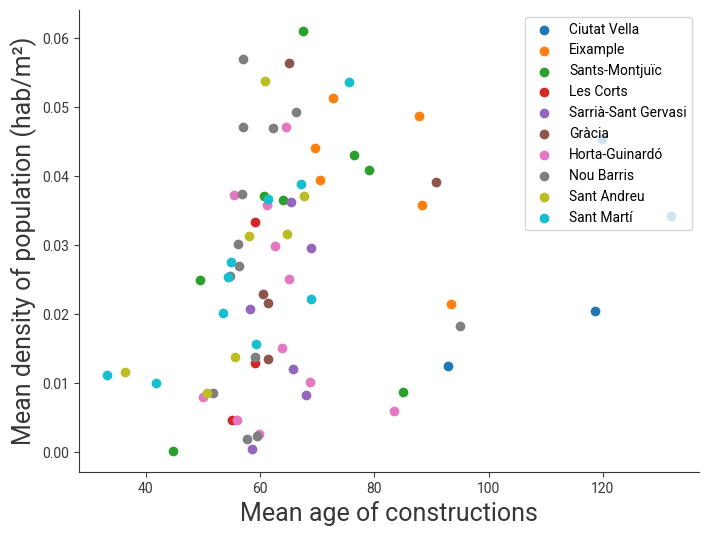

In [14]:
fig, ax = plt.subplots(figsize=(8,6))
for districte in barris_df['DISTRICTE'].unique():
    tmp = barris_df[barris_df['DISTRICTE']==districte]
    nom_districte = districtes.set_index('DISTRICTE')['NOM_DISTRICTE'][districte]
    ax.scatter(tmp['Edat_mitjana'], tmp['density'], label=nom_districte)

ax.legend(loc='upper right', frameon=True)

ax.set_xlabel("Mean age of constructions")
ax.set_ylabel("Mean density of population (hab/m²)")

Text(120, 250, 'Mean = 69.4')

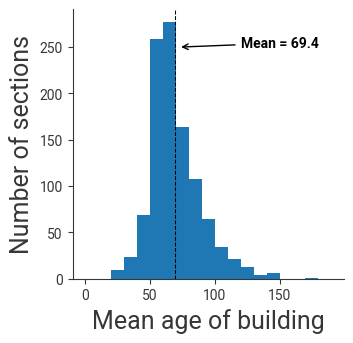

In [15]:
fig, ax = plt.subplots(figsize=(3.5,3.5))
plot_df.Edat_mitjana.hist(grid=False, bins=np.arange(20)*10)
ax.set_xlabel("Mean age of building")
ax.set_ylabel("Number of sections")
m = plot_df.Edat_mitjana.mean()
ax.axvline(x=m, color='k', linestyle='--', linewidth=0.75)

y = 250
ax.annotate(
    f"Mean = {m:.1f}",
    xy=(72, y),
    xytext=(120, y),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
    weight='bold'
)

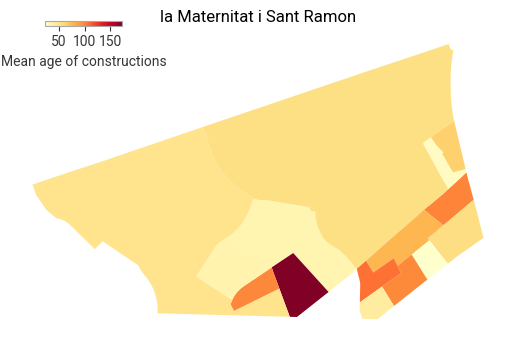

In [16]:
def barrio_plot(barrio):
    fig, ax = plt.subplots()
    barrio.plot(ax=ax, column='Edat_mitjana', cmap='YlOrRd')
    ax.axis(False)
    ax.set_title(barrio['NOM_BARRI'].unique()[0])

    # color bar
    cax = fig.add_axes([0.18, 0.82, 0.12, 0.01])
    m, M = df.Edat_mitjana.min(), df.Edat_mitjana.max()
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=m, vmax=M))
    sm._A = []
    cbar = plt.colorbar(sm, cax=cax, drawedges=False, orientation="horizontal")
    cbar.outline.set_edgecolor('darkgray')
    cbar.set_label("Mean age of constructions", fontsize=10)


gdf = seccio_censal.merge(df).merge(barris[['BARRI', 'NOM_BARRI']])

barrio_id = 20
barrio = gpd.GeoDataFrame(gdf[gdf.BARRI == barrio_id])
barrio_plot(barrio)
# for barrio_id in gdf['BARRI'].unique():
#     barrio = gpd.GeoDataFrame(gdf[gdf.BARRI == barrio_id])
#     barrio_plot(barrio)

73 rows × 4 columns

In [26]:
gdf.merge(barris, on=["BARRI", "DISTRICTE"])

1055 rows × 9 columns

In [30]:
df.groupby('BARRI').Edat_mitjana.max()

BARRI
1     146.9
2     173.5
3     110.6
4     134.1
5      86.9
      ...  
69     49.3
70     78.0
71     70.4
72    101.1
73     86.9
Name: Edat_mitjana, Length: 73, dtype: float64